In [1]:
import hoda
import tensorly as tl

tl.set_backend('cupy', local_threadsafe=False)
print(tl.get_backend())
%pip install toeplitzlda
%pip freeze | grep moabb

cupy

[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
moabb==1.0.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation

paradigm = P300(resample=48)
datasets = [
    #BI2012(),
    #BI2013a(),
    #BI2014a(),
    #BI2014b(),
    #BI2015a(),
    #BI2015b(),
    #BNCI2014_008(),
    #BNCI2014_009(),
    #EPFLP300(),
    BNCI2015_003(),
    #Cattan2019_VR(),
    #Huebner2017(),
    #Huebner2018(),
    #Lee2019_ERP(),
    #Sosulski2019(),
]

evaluation = WithinSessionEvaluation(
    paradigm=paradigm,
    datasets=datasets,
    overwrite=False,
    random_state=42,
    n_jobs=8,
    suffix='sfreq-48',
)

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


In [3]:
from sklearn.pipeline import Pipeline
from hoda.hoda import HODA, BTTDA,  GreedyBTTDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from hoda.classification import ToeplitzLDAWrapper, SelectF
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from mne.decoding import Scaler
from sklearn.linear_model import LogisticRegression
from hoda.tensorize import  Vectorize, Tensorize

pipelines = dict()


hoda_params = dict(
    max_iter=128,
    tol=1e-8,
    init ='eye',
    random_state=42,
    shrinkage='lw',
    solver='lanczos',
    taper=False,
    forward=False,
    obj='rt',
    toeplitz=None,
    delta=None,
)


pipelines['HODA'] = Pipeline([
    ('tensor', Tensorize()),
    ('clf', GridSearchCV(
        Pipeline([
            ('hoda', HODA(**hoda_params)),
            ('vec', Vectorize()),
            ('zscore', StandardScaler()),
            ('lda', LDA(shrinkage='auto', solver='lsqr')),
        ]),
        param_grid=dict(hoda__rank=[1,2,4,8]),
        n_jobs=4
    )),
])

pipelines['BTTDA_16'] = Pipeline([
    ('bttda', GreedyBTTDA(
        max_blocks=16,
        truncate=True,
        hoda_params=dict(
            **hoda_params,
        ),
        extra_train_info=False,
        verbose=False
    )),
    ('vec', Vectorize()),
    ('zscore', StandardScaler()),
    ('lda', LDA(shrinkage='auto', solver='lsqr'))
])
pipelines['tLDA'] = ToeplitzLDAWrapper()


In [4]:
#import warnings
#warnings.filterwarnings("ignore")

results = evaluation.process(pipelines)

BNCI2015-003-WithinSession:   0%|                                                                                                      | 0/10 [00:00<?, ?it/s]

MNE_DATA is not already configured. It will be set to default location in the home directory - /root/mne_data
All datasets will be downloaded to this location, if anything is already downloaded, please move manually to this location


/usr/local/lib/python3.10/dist-packages/moabb/datasets/download.py:55: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BNCI_PATH"
  set_config(key, get_config("MNE_DATA"))


No hdf5_path provided, models will not be saved.


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<fro

...

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))
BNCI2015-003-WithinSession:  80%|██████████████████████████████████████████████████████████████████████████▍                  | 8/10 [47:42<11:07, 333.89s/it]

No hdf5_path provided, models will not be saved.


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))
BNCI2015-003-WithinSession:  90%|███████████████████████████████████████████████████████████████████████████████████▋         | 9/10 [52:52<05:26, 326.27s/it]

No hdf5_path provided, models will not be saved.


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_function_transformer.py:394: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))
BNCI2015-003-WithinSession: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [58:06<00:00, 348.68s/it]


In [5]:
results

,score,time,samples,subject,session,channels,n_sessions,dataset,pipeline
0,0.777537,96.927971,5400.0,1,0,8,1,BNCI2015-003,BTTDA_16
1,0.936457,99.133453,5400.0,2,0,8,1,BNCI2015-003,BTTDA_16
2,0.812533,55.549110,1800.0,3,0,8,1,BNCI2015-003,BTTDA_16
3,0.869978,31.205097,1800.0,4,0,8,1,BNCI2015-003,BTTDA_16
4,0.873711,89.724556,1800.0,5,0,8,1,BNCI2015-003,BTTDA_16
5,0.666822,67.606697,1800.0,6,0,8,1,BNCI2015-003,BTTDA_16
6,0.809344,65.930511,1800.0,7,0,8,1,BNCI2015-003,BTTDA_16
7,0.912533,61.609138,1800.0,8,0,8,1,BNCI2015-003,BTTDA_16
8,0.893144,61.261330,1800.0,9,0,8,1,BNCI2015-003,BTTDA_16
9,0.896078,62.363926,1800.0,10,0,8,1,BNCI2015-003,BTTDA_16


In [6]:
results.groupby(['dataset','session', 'pipeline']).aggregate('std') 

/tmp/ipykernel_199/2642956697.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  results.groupby(['dataset','session', 'pipeline']).aggregate('std')


score       time      samples  channels  \
dataset      session pipeline                                               
BNCI2014-009 0       tLDA      0.062341   0.004085     0.000000       0.0   
             1       tLDA      0.025763   0.002768     0.000000       0.0   
             2       tLDA      0.048286   0.003479     0.000000       0.0   
BNCI2015-003 0       BTTDA_16  0.080225  20.807651  1517.893277       0.0   
                     HODA      0.080505   5.380622  1517.893277       0.0   
                     tLDA      0.073881   0.014682  1517.893277       0.0   

                               n_sessions  
dataset      session pipeline              
BNCI2014-009 0       tLDA             0.0  
             1       tLDA             0.0  
             2       tLDA             0.0  
BNCI2015-003 0       BTTDA_16         0.0  
                     HODA             0.0  
                     tLDA             0.0

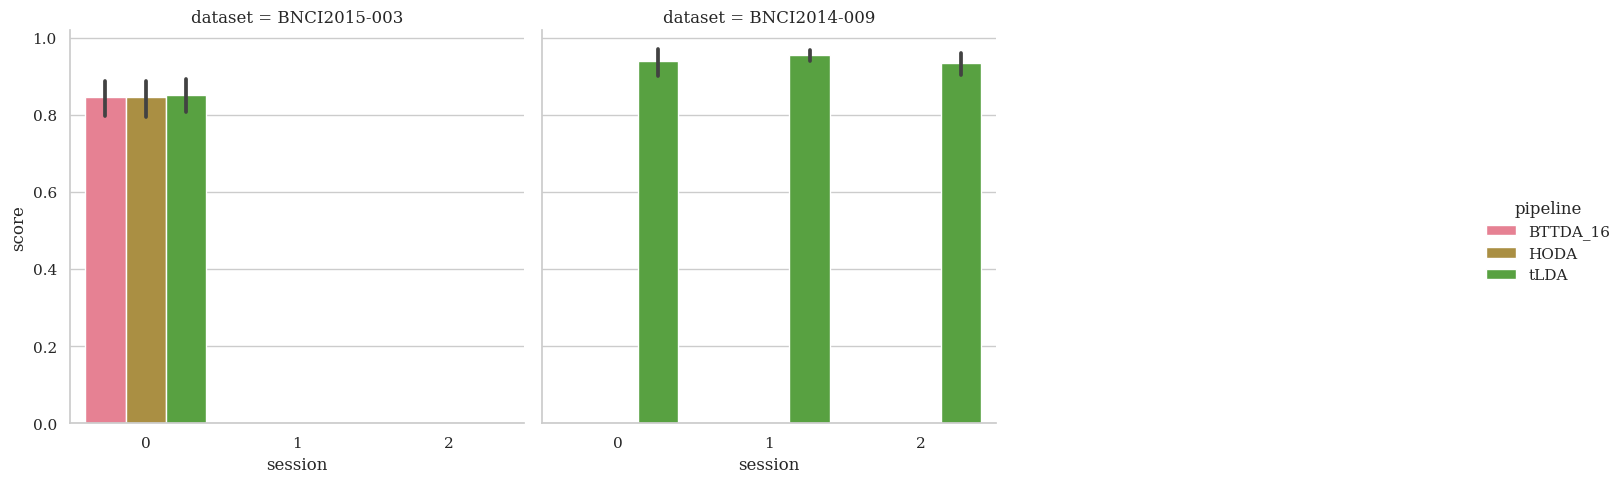

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

order = results.groupby('pipeline')
order = order.score.aggregate('mean')
order = order.sort_values()


sns.catplot(data=results , x='session', y='score', col='dataset',hue='pipeline', col_wrap=3,kind='bar')
plt.show()

In [8]:
from moabb.analysis.meta_analysis import compute_dataset_statistics, find_significant_differences
from moabb.analysis.plotting import summary_plot
import matplotlib.pyplot as plt

stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
_ = summary_plot(P, T)
plt.show()

AssertionError: provided order does not have all columns of dataframe

In [ ]:
from moabb.analysis.plotting import meta_analysis_plot, paired_plot
_ = meta_analysis_plot(stats,'BTTDA_8',  'tLDA')
plt.show()
_  = paired_plot(results,  'tLDA','BTTDA_8')
plt.show()
